In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tqdm import tqdm
import pickle

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

import warnings
warnings.filterwarnings('ignore')

device = torch.device('mps' if torch.backends.mps.is_available() else 'cpu')
print(f"Usando dispositivo: {device}")

Usando dispositivo: mps


## 1. Carga de Datos

In [3]:
X_train_scaled = np.load('../data/processed/X_train_scaled.npy')
X_test_scaled = np.load('../data/processed/X_test_scaled.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test = np.load('../data/processed/y_test.npy')

X_train_eng_scaled = np.load('../data/processed/X_train_eng_scaled.npy')
X_test_eng_scaled = np.load('../data/processed/X_test_eng_scaled.npy')

print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_train_eng_scaled shape: {X_train_eng_scaled.shape}")
print(f"y_train shape: {y_train.shape}")

X_train_scaled shape: (67229, 31)
X_train_eng_scaled shape: (67229, 56)
y_train shape: (67229,)


## 2. Preparación de DataLoaders

In [4]:
def create_dataloaders(X_train, X_test, y_train, y_test, batch_size=64):
    """
    Crea DataLoaders de PyTorch a partir de arrays numpy.
    """
    X_train_tensor = torch.FloatTensor(X_train)
    y_train_tensor = torch.FloatTensor(y_train).reshape(-1, 1)
    X_test_tensor = torch.FloatTensor(X_test)
    y_test_tensor = torch.FloatTensor(y_test).reshape(-1, 1)
    
    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset = TensorDataset(X_test_tensor, y_test_tensor)
    
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
    
    return train_loader, test_loader

train_loader, test_loader = create_dataloaders(X_train_scaled, X_test_scaled, y_train, y_test)
train_loader_eng, test_loader_eng = create_dataloaders(X_train_eng_scaled, X_test_eng_scaled, y_train, y_test)

print("DataLoaders creados.")

DataLoaders creados.


## 3. Definición de Arquitecturas de Redes Neuronales

In [5]:
class NeuralNetRegressor(nn.Module):
    """
    Red neuronal feedforward para regresión.
    """
    def __init__(self, input_size, hidden_sizes, dropout_rate=0.3):
        super(NeuralNetRegressor, self).__init__()
        
        layers = []
        prev_size = input_size
        
        for hidden_size in hidden_sizes:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(nn.ReLU())
            layers.append(nn.BatchNorm1d(hidden_size))
            layers.append(nn.Dropout(dropout_rate))
            prev_size = hidden_size
        
        layers.append(nn.Linear(prev_size, 1))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.network(x)

print("Arquitectura de red neuronal definida.")

Arquitectura de red neuronal definida.


## 4. Funciones de Entrenamiento y Evaluación

In [6]:
def train_model(model, train_loader, test_loader, criterion, optimizer, num_epochs=100, device='cpu'):
    """
    Entrena el modelo y retorna las métricas de entrenamiento.
    """
    train_losses = []
    test_losses = []
    
    model.to(device)
    
    for epoch in range(num_epochs):
        model.train()
        epoch_train_loss = 0.0
        
        for X_batch, y_batch in train_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            
            epoch_train_loss += loss.item()
        
        avg_train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(avg_train_loss)
        
        model.eval()
        epoch_test_loss = 0.0
        
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                X_batch, y_batch = X_batch.to(device), y_batch.to(device)
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                epoch_test_loss += loss.item()
        
        avg_test_loss = epoch_test_loss / len(test_loader)
        test_losses.append(avg_test_loss)
        
        if (epoch + 1) % 20 == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Test Loss: {avg_test_loss:.4f}")
    
    return train_losses, test_losses

def evaluate_model(model, data_loader, device='cpu'):
    """
    Evalúa el modelo y retorna las predicciones.
    """
    model.eval()
    predictions = []
    actuals = []
    
    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch = X_batch.to(device)
            outputs = model(X_batch)
            predictions.extend(outputs.cpu().numpy())
            actuals.extend(y_batch.numpy())
    
    predictions = np.array(predictions).flatten()
    actuals = np.array(actuals).flatten()
    
    return predictions, actuals

def compute_metrics(y_true, y_pred, model_name):
    """
    Calcula y muestra las métricas de evaluación.
    """
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{'='*50}")
    print(f"Resultados para: {model_name}")
    print(f"{'='*50}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE:  {mae:.4f}")
    print(f"R2:   {r2:.4f}")
    
    return {
        'model': model_name,
        'rmse': rmse,
        'mae': mae,
        'r2': r2
    }

## 5. Red Neuronal con 1 Capa Oculta (Features Originales)

In [7]:
print("Entrenando Red Neuronal con 1 capa oculta (features originales)...\n")

input_size = X_train_scaled.shape[1]
model_1layer = NeuralNetRegressor(input_size, hidden_sizes=[64], dropout_rate=0.2)

criterion = nn.MSELoss()
optimizer = optim.Adam(model_1layer.parameters(), lr=0.001, weight_decay=1e-5)

train_losses_1layer, test_losses_1layer = train_model(
    model_1layer, train_loader, test_loader, criterion, optimizer, num_epochs=100, device=device
)

y_pred_1layer, y_true = evaluate_model(model_1layer, test_loader, device=device)
results_nn_1layer = compute_metrics(y_true, y_pred_1layer, "NN 1-Layer")

Entrenando Red Neuronal con 1 capa oculta (features originales)...

Epoch [20/100], Train Loss: 20278462.0866, Test Loss: 4998374.3772
Epoch [40/100], Train Loss: 16783690.1960, Test Loss: 4142950.1275
Epoch [60/100], Train Loss: 15305766.5678, Test Loss: 3356989.9989
Epoch [80/100], Train Loss: 14592089.5131, Test Loss: 4088301.8314
Epoch [100/100], Train Loss: 14004864.0476, Test Loss: 3609824.5865

Resultados para: NN 1-Layer
RMSE: 1900.0722
MAE:  1358.5765
R2:   0.1526


## 6. Red Neuronal con 2 Capas Ocultas (Features Originales)

In [8]:
print("Entrenando Red Neuronal con 2 capas ocultas (features originales)...\n")

model_2layers = NeuralNetRegressor(input_size, hidden_sizes=[128, 64], dropout_rate=0.2)

criterion = nn.MSELoss()
optimizer = optim.Adam(model_2layers.parameters(), lr=0.001, weight_decay=1e-5)

train_losses_2layers, test_losses_2layers = train_model(
    model_2layers, train_loader, test_loader, criterion, optimizer, num_epochs=100, device=device
)

y_pred_2layers, _ = evaluate_model(model_2layers, test_loader, device=device)
results_nn_2layers = compute_metrics(y_true, y_pred_2layers, "NN 2-Layers")

Entrenando Red Neuronal con 2 capas ocultas (features originales)...

Epoch [20/100], Train Loss: 11851867.6085, Test Loss: 3041122.4258
Epoch [40/100], Train Loss: 9870166.2461, Test Loss: 2282425.3226
Epoch [60/100], Train Loss: 9298922.7995, Test Loss: 2342048.7875
Epoch [80/100], Train Loss: 8973247.3899, Test Loss: 2131840.5684
Epoch [100/100], Train Loss: 8799086.3225, Test Loss: 2402299.0081

Resultados para: NN 2-Layers
RMSE: 1549.9638
MAE:  1032.9264
R2:   0.4361


## 7. Red Neuronal con Feature Engineering (2 capas)

In [9]:
print("Entrenando Red Neuronal con 2 capas ocultas (features engineered)...\n")

input_size_eng = X_train_eng_scaled.shape[1]
model_2layers_eng = NeuralNetRegressor(input_size_eng, hidden_sizes=[128, 64], dropout_rate=0.2)

criterion = nn.MSELoss()
optimizer = optim.Adam(model_2layers_eng.parameters(), lr=0.001, weight_decay=1e-5)

train_losses_2layers_eng, test_losses_2layers_eng = train_model(
    model_2layers_eng, train_loader_eng, test_loader_eng, criterion, optimizer, num_epochs=100, device=device
)

y_pred_2layers_eng, _ = evaluate_model(model_2layers_eng, test_loader_eng, device=device)
results_nn_2layers_eng = compute_metrics(y_true, y_pred_2layers_eng, "NN 2-Layers + FE")

Entrenando Red Neuronal con 2 capas ocultas (features engineered)...

Epoch [20/100], Train Loss: 13318168.2659, Test Loss: 2644203.9148
Epoch [40/100], Train Loss: 11209440.5442, Test Loss: 2839994.2059
Epoch [60/100], Train Loss: 10195220.8578, Test Loss: 2393507.9955
Epoch [80/100], Train Loss: 9977114.2171, Test Loss: 2180434.7601
Epoch [100/100], Train Loss: 9428050.5940, Test Loss: 2537930.9860

Resultados para: NN 2-Layers + FE
RMSE: 1593.0593
MAE:  1086.1508
R2:   0.4043


## 8. Visualización de Curvas de Aprendizaje

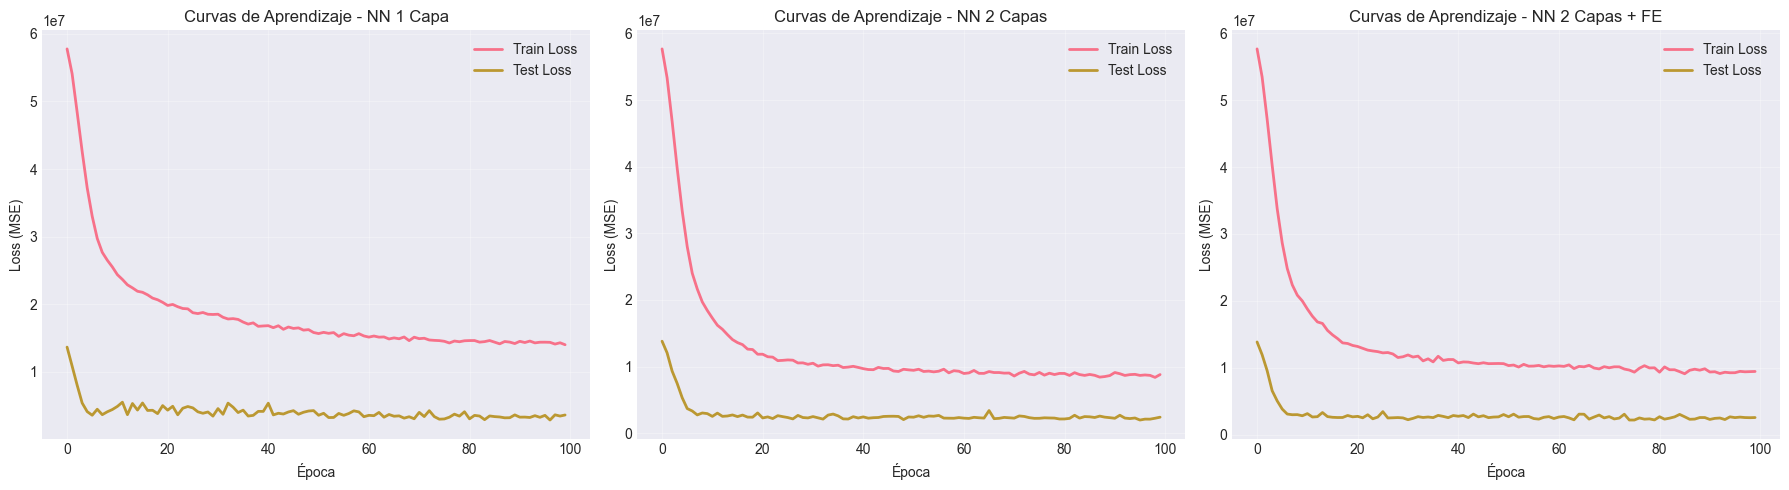

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(train_losses_1layer, label='Train Loss', linewidth=2)
axes[0].plot(test_losses_1layer, label='Test Loss', linewidth=2)
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Loss (MSE)')
axes[0].set_title('Curvas de Aprendizaje - NN 1 Capa')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(train_losses_2layers, label='Train Loss', linewidth=2)
axes[1].plot(test_losses_2layers, label='Test Loss', linewidth=2)
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Loss (MSE)')
axes[1].set_title('Curvas de Aprendizaje - NN 2 Capas')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(train_losses_2layers_eng, label='Train Loss', linewidth=2)
axes[2].plot(test_losses_2layers_eng, label='Test Loss', linewidth=2)
axes[2].set_xlabel('Época')
axes[2].set_ylabel('Loss (MSE)')
axes[2].set_title('Curvas de Aprendizaje - NN 2 Capas + FE')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../figures/nn_learning_curves.png', dpi=300, bbox_inches='tight')
plt.show()

## 9. Visualización de Predicciones

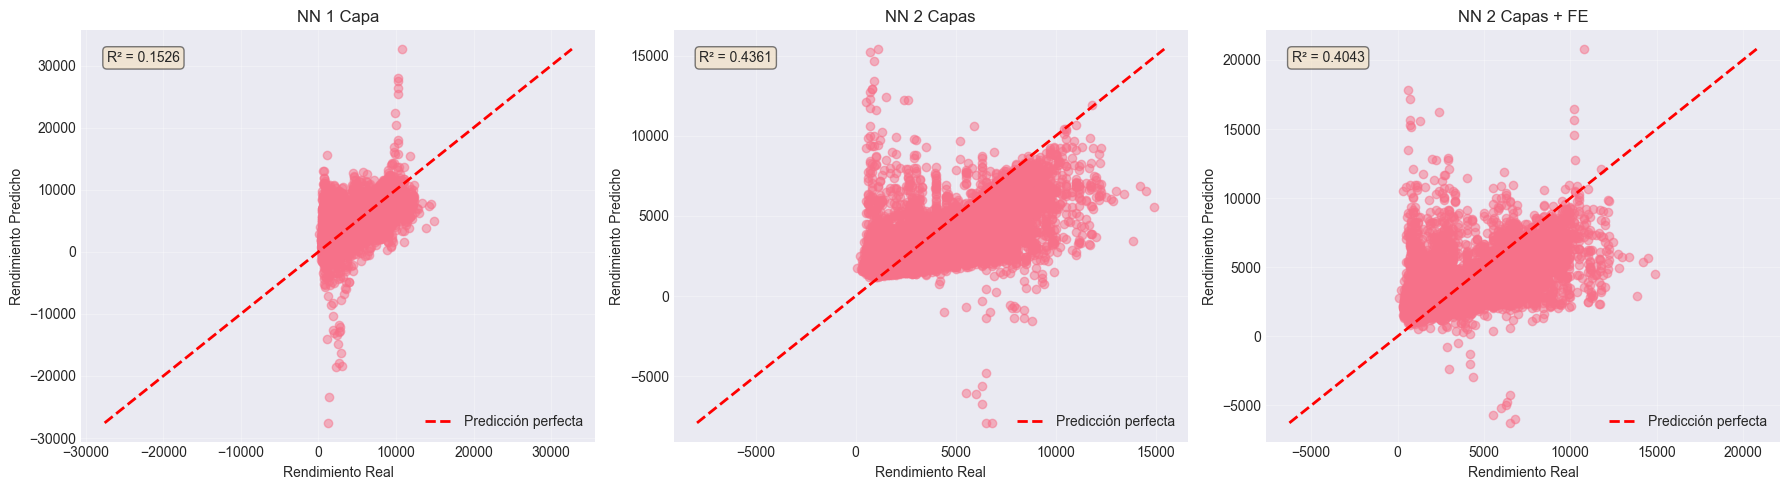

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

def plot_predictions(y_true, y_pred, title, ax):
    ax.scatter(y_true, y_pred, alpha=0.5)
    min_val = min(y_true.min(), y_pred.min())
    max_val = max(y_true.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Predicción perfecta')
    ax.set_xlabel('Rendimiento Real')
    ax.set_ylabel('Rendimiento Predicho')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    r2 = r2_score(y_true, y_pred)
    ax.text(0.05, 0.95, f'R² = {r2:.4f}', 
            transform=ax.transAxes, verticalalignment='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plot_predictions(y_true, y_pred_1layer, 'NN 1 Capa', axes[0])
plot_predictions(y_true, y_pred_2layers, 'NN 2 Capas', axes[1])
plot_predictions(y_true, y_pred_2layers_eng, 'NN 2 Capas + FE', axes[2])

plt.tight_layout()
plt.savefig('../figures/nn_predictions.png', dpi=300, bbox_inches='tight')
plt.show()

## 10. Comparación con Todos los Modelos Anteriores

In [12]:
with open('../results/linear_regression_results.pkl', 'rb') as f:
    lr_results = pickle.load(f)

with open('../results/xgboost_results.pkl', 'rb') as f:
    xgb_results = pickle.load(f)

with open('../results/feature_engineering_results.pkl', 'rb') as f:
    fe_results = pickle.load(f)

# Usar las claves correctas que existen en cada archivo
all_results = pd.DataFrame([
    lr_results['lr_x_val'],      # usar 'val' en lugar de 'test' para LR
    lr_results['lr_z_val'],      # usar 'val' en lugar de 'test' para LR
    xgb_results['xgb_x_test'],   # xgb sí tiene 'test'
    xgb_results['xgb_z_test'],   # xgb sí tiene 'test'
    fe_results['lr_x_eng'],      # FE usa nombres sin train/val/test
    fe_results['xgb_x_eng'],     # FE usa nombres sin train/val/test
    results_nn_1layer,
    results_nn_2layers,
    results_nn_2layers_eng
])

print("\n" + "="*80)
print("COMPARACIÓN DE MODELOS")
print("="*80)
print(all_results.to_string(index=False))
print("="*80)


COMPARACIÓN DE MODELOS
                                 model        rmse         mae        r2
    Linear Regression (X) - Validation 3186.590903 1822.042463  0.095716
Linear Regression (Z-PCA) - Validation 3128.231027 1785.745667  0.128535
              XGBoost (X) - Validation 1179.553865  590.828236  0.876095
          XGBoost (Z-PCA) - Validation 2801.135385 1675.557816  0.301252
                           LR (X + FE) 3130.835632 1792.921431 -1.300761
                          XGB (X + FE) 1053.919369  609.628511  0.739285
                            NN 1-Layer 1900.072235 1358.576538  0.152595
                           NN 2-Layers 1549.963790 1032.926392  0.436110
                      NN 2-Layers + FE 1593.059321 1086.150757  0.404317


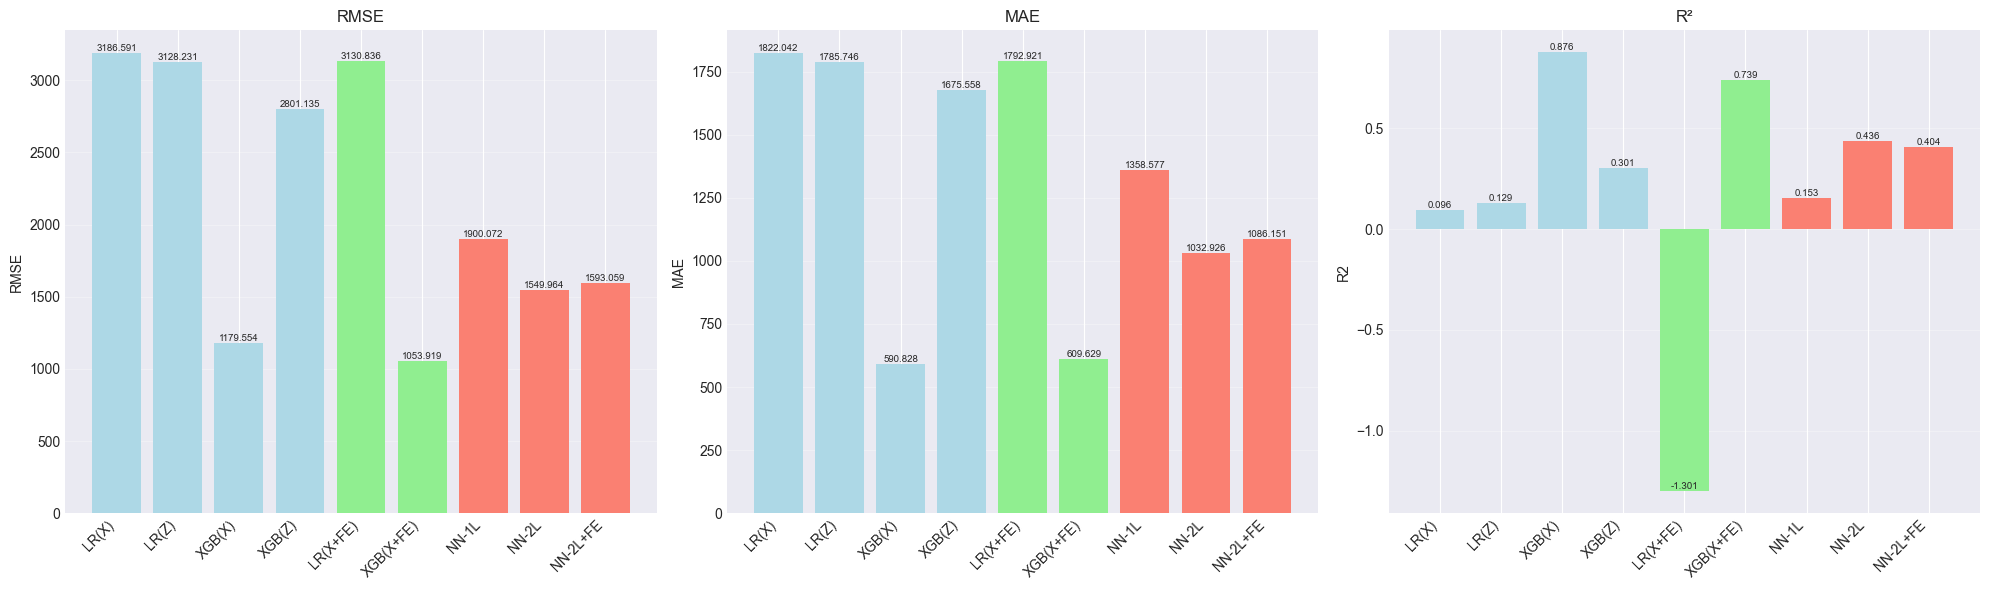

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

metrics = ['rmse', 'mae', 'r2']
titles = ['RMSE', 'MAE', 'R²']
model_labels = ['LR(X)', 'LR(Z)', 'XGB(X)', 'XGB(Z)', 
                'LR(X+FE)', 'XGB(X+FE)', 
                'NN-1L', 'NN-2L', 'NN-2L+FE']

colors = ['lightblue']*4 + ['lightgreen']*2 + ['salmon']*3

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    values = all_results[metric].values
    
    axes[idx].bar(range(len(values)), values, color=colors)
    axes[idx].set_xticks(range(len(values)))
    axes[idx].set_xticklabels(model_labels, rotation=45, ha='right')
    axes[idx].set_ylabel(metric.upper())
    axes[idx].set_title(title)
    axes[idx].grid(True, alpha=0.3, axis='y')
    
    for i, v in enumerate(values):
        axes[idx].text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=7)

plt.tight_layout()
plt.savefig('../figures/complete_comparison_with_nn.png', dpi=300, bbox_inches='tight')
plt.show()

## 11. Guardar Modelos

In [14]:
torch.save(model_1layer.state_dict(), '../models/nn_1layer.pth')
torch.save(model_2layers.state_dict(), '../models/nn_2layers.pth')
torch.save(model_2layers_eng.state_dict(), '../models/nn_2layers_eng.pth')

print("Modelos de redes neuronales guardados.")

Modelos de redes neuronales guardados.


In [15]:
nn_results = {
    'nn_1layer': results_nn_1layer,
    'nn_2layers': results_nn_2layers,
    'nn_2layers_eng': results_nn_2layers_eng,
    'train_losses_1layer': train_losses_1layer,
    'test_losses_1layer': test_losses_1layer,
    'train_losses_2layers': train_losses_2layers,
    'test_losses_2layers': test_losses_2layers,
    'train_losses_2layers_eng': train_losses_2layers_eng,
    'test_losses_2layers_eng': test_losses_2layers_eng
}

with open('../results/neural_network_results.pkl', 'wb') as f:
    pickle.dump(nn_results, f)

print("Resultados de redes neuronales guardados.")

Resultados de redes neuronales guardados.
